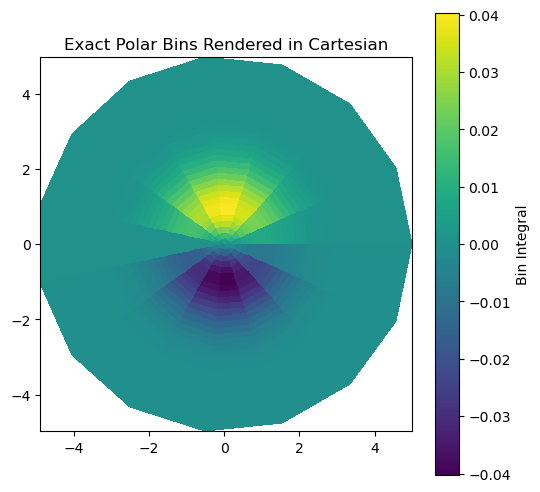

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

# --- Define bin edges ---
r_edges = np.linspace(0, 5, 32)
theta_edges = np.linspace(0, 2*np.pi, 16)

Nr = len(r_edges) - 1
Nt = len(theta_edges) - 1

# --- Compute bin integrals (same as yours, simplified) ---
def integrand(theta, r):
    return np.exp(-r**2/2) * r * np.sin(theta)   # purely radial

Z = np.zeros((Nr, Nt))

for i in range(Nr):
    for j in range(Nt):
        result, _ = integrate.dblquad(
            integrand,
            r_edges[i], r_edges[i+1],
            lambda r: theta_edges[j],
            lambda r: theta_edges[j+1]
        )
        Z[i, j] = result

# --- Build edge grid in polar ---
Theta_edges, R_edges = np.meshgrid(theta_edges, r_edges)

# --- Convert edges to Cartesian ---
X_edges = R_edges * np.cos(Theta_edges)
Y_edges = R_edges * np.sin(Theta_edges)

# --- Plot ---
plt.figure(figsize=(6,6))
plt.pcolormesh(X_edges, Y_edges, Z, shading='flat')
plt.gca().set_aspect('equal')
plt.colorbar(label="Bin Integral")
plt.title("Exact Polar Bins Rendered in Cartesian")
plt.show()
